In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def build_workcell_semantic_network():
    # Create a Directed Graph for explicit subject-predicate-object relationships
    G = nx.DiGraph()

    # --- 1. DEFINE NODES WITH CATEGORY ATTRIBUTES ---
    nodes_data = [
        # System & Master Host
        ("Workcell Host Computer", {"type": "Computer", "category": "Control"}),
        ("Manufacturing Workcell", {"type": "System", "category": "Infrastructure"}),

        # Physical Equipment
        ("Industrial Robot", {"type": "Equipment", "category": "Physical"}),
        ("CNC Mill", {"type": "Equipment", "category": "Physical"}),
        ("Conveyor System", {"type": "Equipment", "category": "Physical"}),

        # Material / Workpiece
        ("Part/Workpiece", {"type": "Material", "category": "Physical"}),

        # Software & Abstract Concepts
        ("Cell Controller Software", {"type": "Software", "category": "Abstract"}),
        ("G-Code Program", {"type": "Data", "category": "Abstract"}),
        ("Production Schedule", {"type": "Data", "category": "Abstract"}),
    ]

    for node, attrs in nodes_data:
        G.add_node(node, **attrs)

    # --- 2. DEFINE EDGES WITH SEMANTIC RELATIONSHIPS ---
    edges_data = [
        # System Topology ("has-a")
        ("Manufacturing Workcell", "Workcell Host Computer", "has_a"),
        ("Manufacturing Workcell", "Industrial Robot", "has_a"),
        ("Manufacturing Workcell", "CNC Mill", "has_a"),
        ("Manufacturing Workcell", "Conveyor System", "has_a"),

        # Control & Communication Relationships
        ("Workcell Host Computer", "Industrial Robot", "controls"),
        ("Workcell Host Computer", "CNC Mill", "monitors"),
        ("Workcell Host Computer", "Conveyor System", "manages"),
        ("Workcell Host Computer", "Cell Controller Software", "runs"),

        # Material Flow & Operations
        ("Conveyor System", "Part/Workpiece", "transports"),
        ("Industrial Robot", "Part/Workpiece", "picks_and_places"),
        ("Industrial Robot", "CNC Mill", "loads_unloads"),

        # Software & Data Flow
        ("Cell Controller Software", "Production Schedule", "executes"),
        ("CNC Mill", "G-Code Program", "executes_program"),
        ("Workcell Host Computer", "G-Code Program", "sends_to_mill"),
    ]

    for source, target, relation in edges_data:
        G.add_edge(source, target, relation=relation)

    return G

In [4]:
def query_semantic_network(g):
  print("=" *60)
  print(" semantic network queries and analysis")
  print("=" *60)
  host_node = "Workcell Host Computer"
  controlled_nodes = [
      target for _, target, attr in g.out_edges(host_node, data=True)
      if attr["relation"] in ["controls", "manages", "monitors"]
  ]
  print(f"\n1. Direct Equipment Managed by '{host_node}':")
  for equipment in controlled_nodes:
      print(f"   • {equipment} ({g.nodes[equipment]['type']})")

  # Query 2: Trace the material path from Conveyor to CNC Mill
  print("\n2. Material Flow Path (Conveyor -> CNC Mill):")
  try:
      path = nx.shortest_path(g, source="Conveyor System", target="CNC Mill")
      print("   " + " ➔ ".join(path))
  except nx.NetworkXNoPath:
      print("   No path found.")

  # Query 3: Inspect all outgoing relationships for the Industrial Robot
  robot_node = "Industrial Robot"
  print(f"\n3. Actions performed by '{robot_node}':")
  for _, target, attr in g.out_edges(robot_node, data=True):
      print(f"   • {attr['relation'].upper()} ➔ {target}")

In [5]:
def visualize_semantic_network(G):
    plt.figure(figsize=(14, 9))

    # Define a visual layout for nodes
    pos = nx.spring_layout(G, k=1.8, seed=42)

    # Color map based on node categories
    color_map = {
        "Control": "#4C72B0",      # Deep Blue
        "Infrastructure": "#55A868",# Muted Green
        "Physical": "#DD8452",      # Soft Red/Orange
        "Abstract": "#C44E52",      # Crimson
    }
    node_colors = [color_map.get(G.nodes[n].get("category"), "#8C8C8C") for n in G.nodes()]

    # Draw Nodes
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, node_size=3200, alpha=0.9
    )

    # Draw Labels for Nodes
    nx.draw_networkx_labels(
        G, pos, font_size=9, font_weight="bold", font_color="white"
    )

    # Draw Edges with Arrows
    nx.draw_networkx_edges(
        G, pos, edge_color="#666666", arrows=True, arrowsize=20, width=1.5,
        connectionstyle="arc3,rad=0.08"
    )

    # Draw Edge Relationship Labels
    edge_labels = nx.get_edge_attributes(G, "relation")
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, font_size=8, font_color="#333333"
    )

    plt.title("Manufacturing Workcell Semantic Network (NetworkX)", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

 semantic network queries and analysis

1. Direct Equipment Managed by 'Workcell Host Computer':
   • Industrial Robot (Equipment)
   • CNC Mill (Equipment)
   • Conveyor System (Equipment)

2. Material Flow Path (Conveyor -> CNC Mill):
   No path found.

3. Actions performed by 'Industrial Robot':
   • PICKS_AND_PLACES ➔ Part/Workpiece
   • LOADS_UNLOADS ➔ CNC Mill


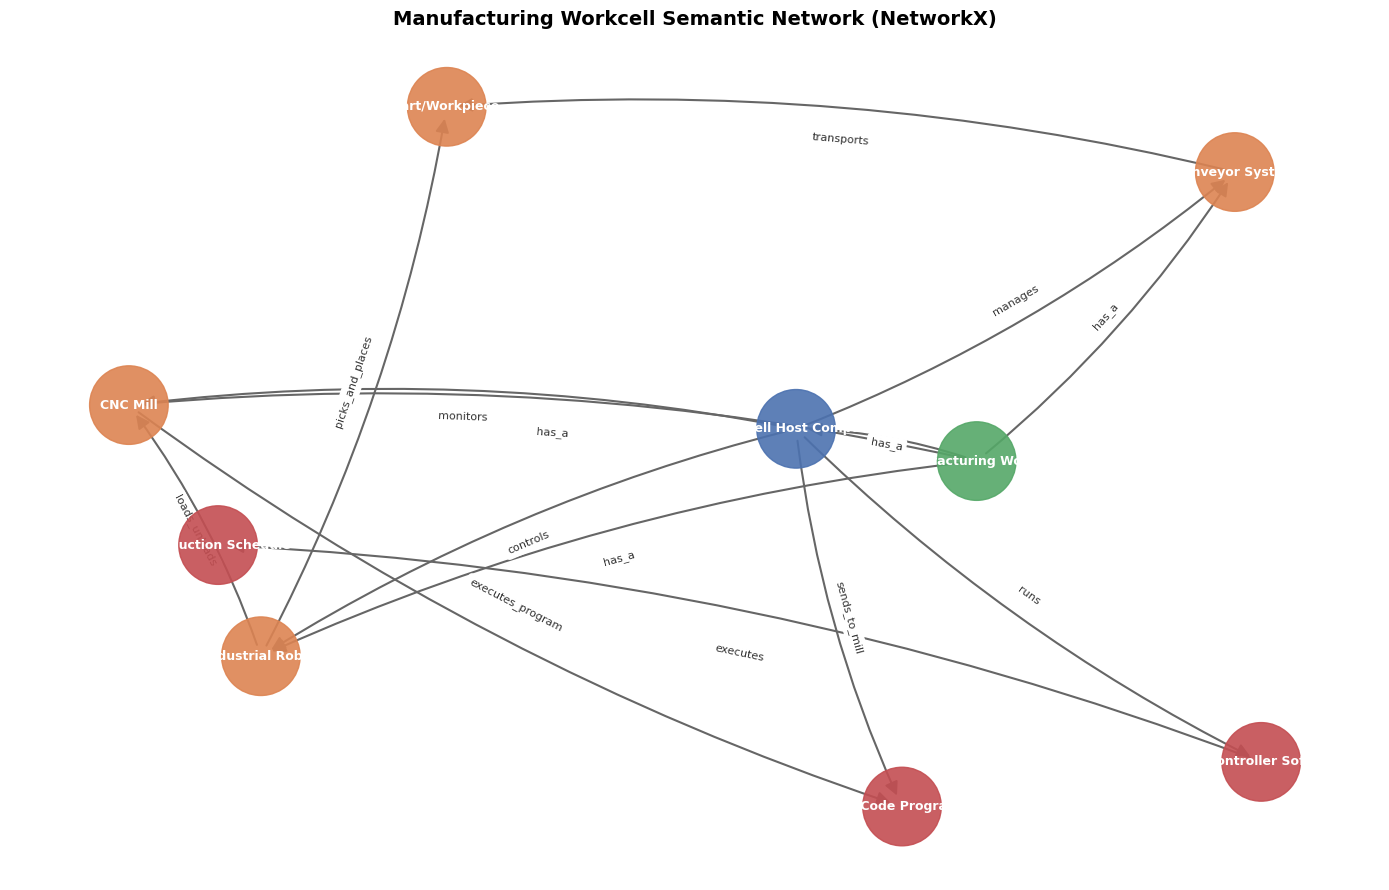

In [6]:
if __name__ == "__main__":
    # 1. Build Network
    workcell_graph = build_workcell_semantic_network()

    # 2. Run Semantic Queries
    query_semantic_network(workcell_graph)

    # 3. Render Visualization
    visualize_semantic_network(workcell_graph)